# Regression

## Imports

In [1]:
import time
import math
import copy

from IPython.display import display
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib widget
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams["figure.constrained_layout.use"] = True

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV

from regression.base.basemodel import BaseModel
from regression.base.basegdmodel import BaseGDModel
from regression.dataset import CaliforniaHousingDataset as Dataset
from regression.pipeline import get_pipeline
from regression.eda.eda import EDA
from regression.logger import get_logger

# Linear regression
from regression.linear_regression.diagnostics import GaussMarkovDiagnostics
from regression.linear_regression.ols import OLS
from regression.linear_regression.wls import WLS
from regression.linear_regression.mbgd import MBGD

# Regularization and features selection
from regression.regularization.ridge_regression import RidgeRegression, RidgeRegressionCV
from regression.regularization.lasso_regression import LassoRegression, LassoRegressionCV
from regression.regularization.elastic_net import ElasticNet, ElasticNetCV
from regression.features_selection.features_selection import \
    forward_selection, backward_elimination, lasso_selection

# Nonlinear basis
from regression.nonlinear_basis.polynomial import PolynomialBasis
from regression.nonlinear_basis.fourier import FourierBasis
from regression.nonlinear_basis.rbf import RBF
from regression.nonlinear_basis.validation_curve import ValidationExperiment
from regression.nonlinear_basis.ablation_study import AblationStudy

# Advanced
from regression.advanced.gpr import GPR
from regression.advanced.irls import IRLS
from regression.advanced.kernel_ridge import KernelRidgeCV
from regression.advanced.bias_variance import BiasVarianceAnalyzer
from regression.advanced.bayes_reg import BayesianLinearRegression

# Evaluation
from regression.evaluation.visualizer import Visualizer
from regression.evaluation.evaluator import Evaluator

# Sensitivity & Robustness
from regression.sensitivity_robustness import (
    sensitivity_split_analysis,
    plot_split_boxplots,
    noise_injection_analysis,
    feature_corruption_analysis,
    plot_loss_curves
)

# Benchmark
from regression.benchmark import benchmark_models

## Dataset

In [2]:
d = Dataset()
d.split()

In [3]:
eda = EDA(d)

### Missing values

In [4]:
display(eda.missing_values())

,feature,missing_count,missing_percent
MedInc,MedInc,0,0.0
HouseAge,HouseAge,0,0.0
AveRooms,AveRooms,0,0.0
AveBedrms,AveBedrms,0,0.0
Population,Population,0,0.0
AveOccup,AveOccup,0,0.0
Latitude,Latitude,0,0.0
Longitude,Longitude,0,0.0
MedHouseVal,MedHouseVal,0,0.0


### Descriptive statistics

In [5]:
display(eda.descriptive_stats())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Target distribution

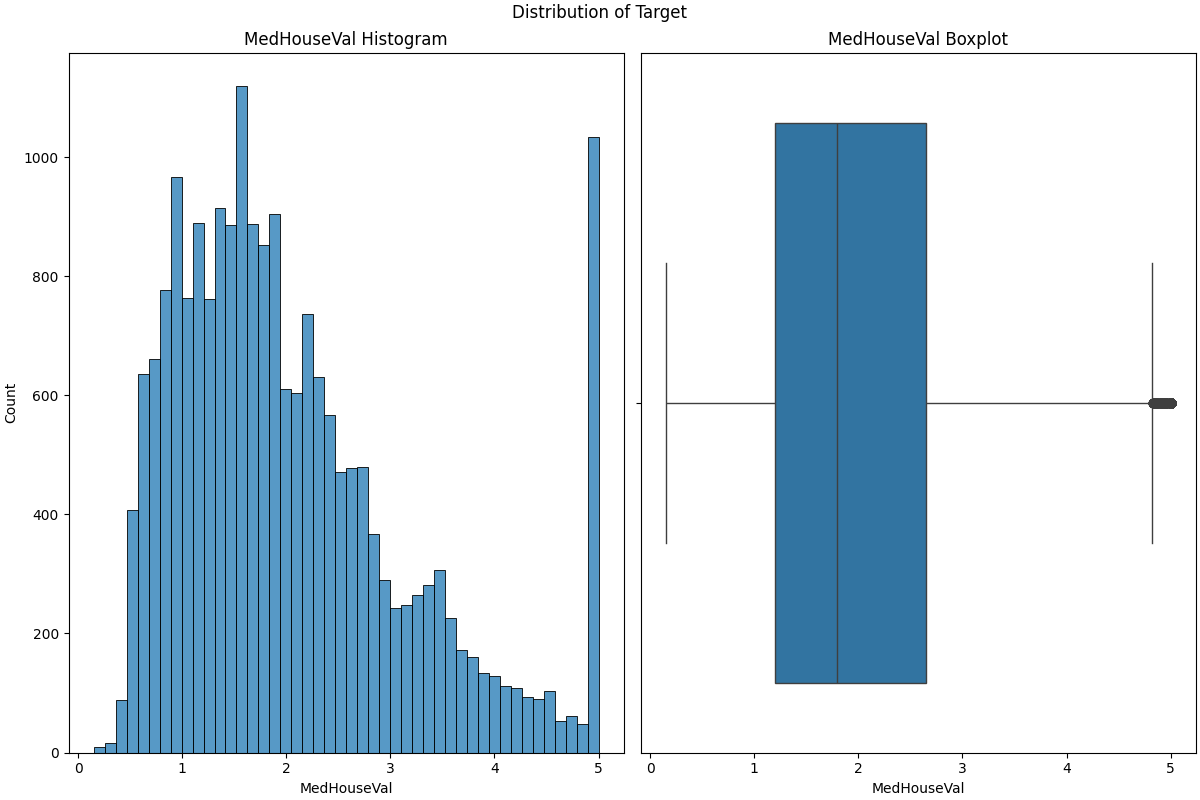

In [6]:
eda.plot_target_distribution()
plt.show()

### Scatter

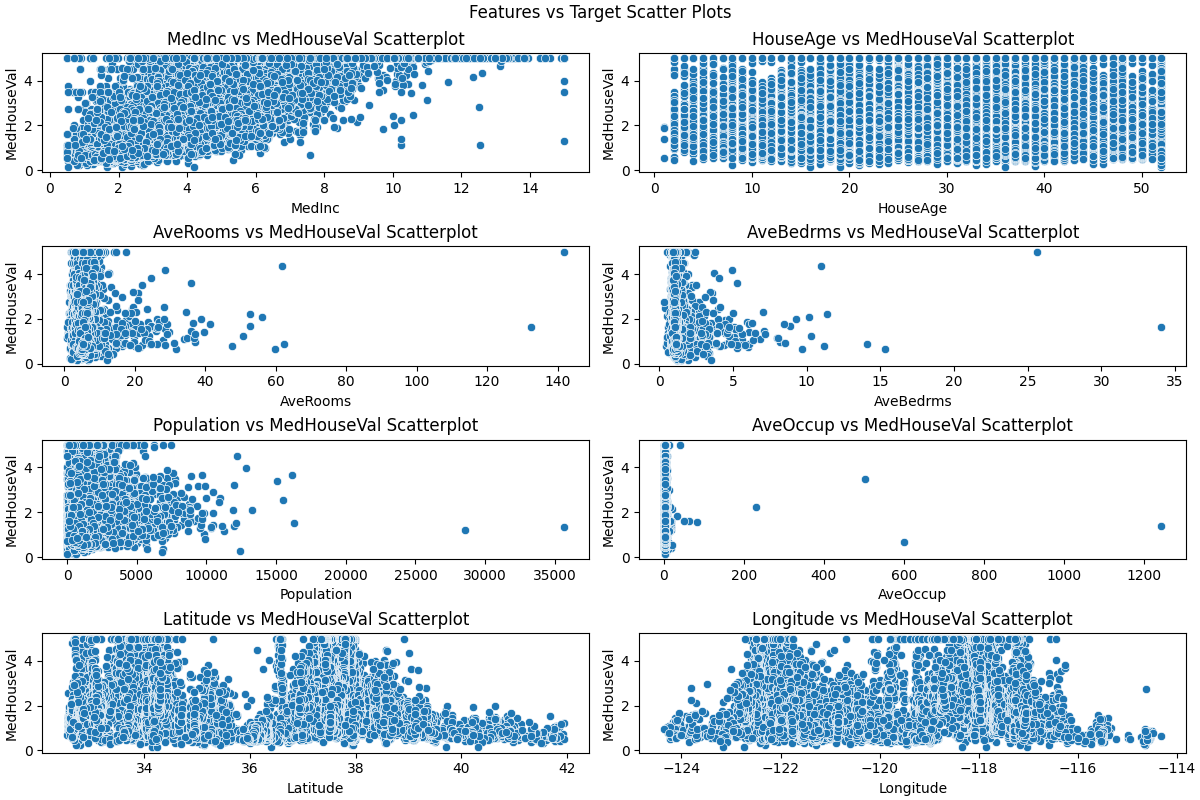

In [7]:
eda.plot_scatter_features_target()
plt.show()

### Correlation matrix

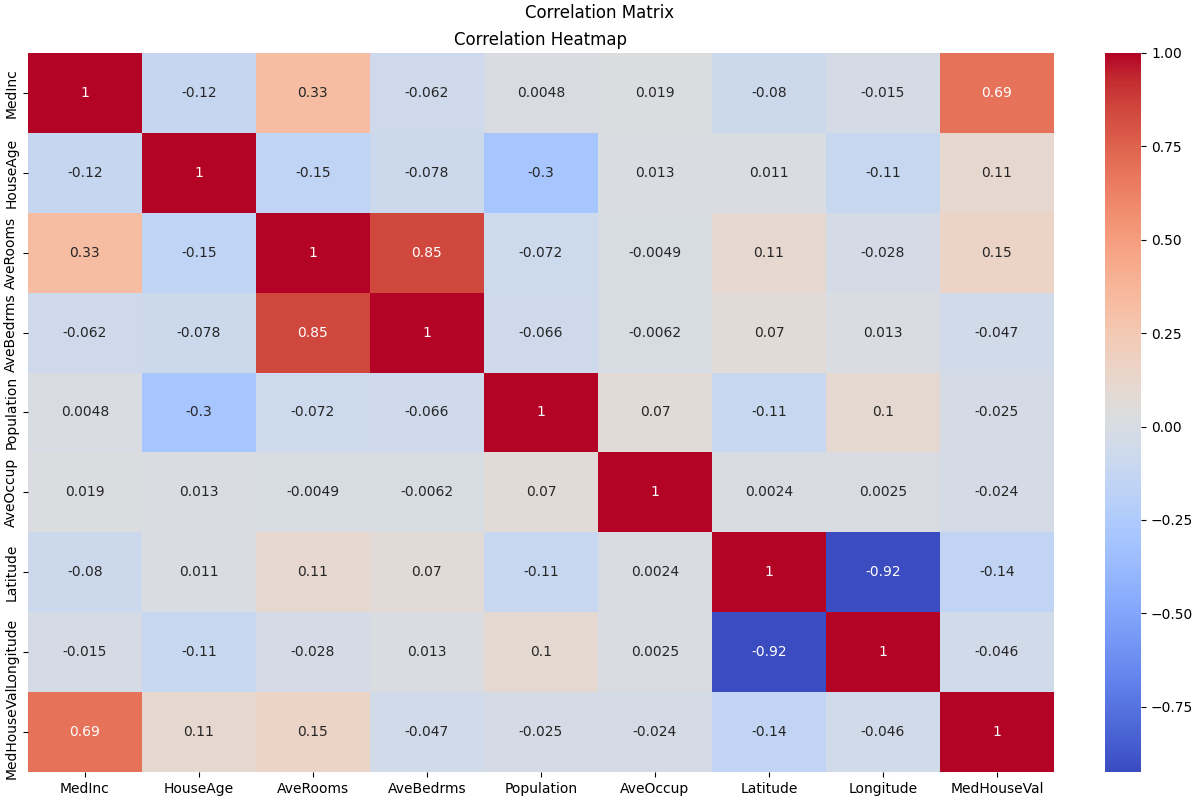

In [4]:
eda.plot_corrrelation_matrix()
plt.show()

### Outliers

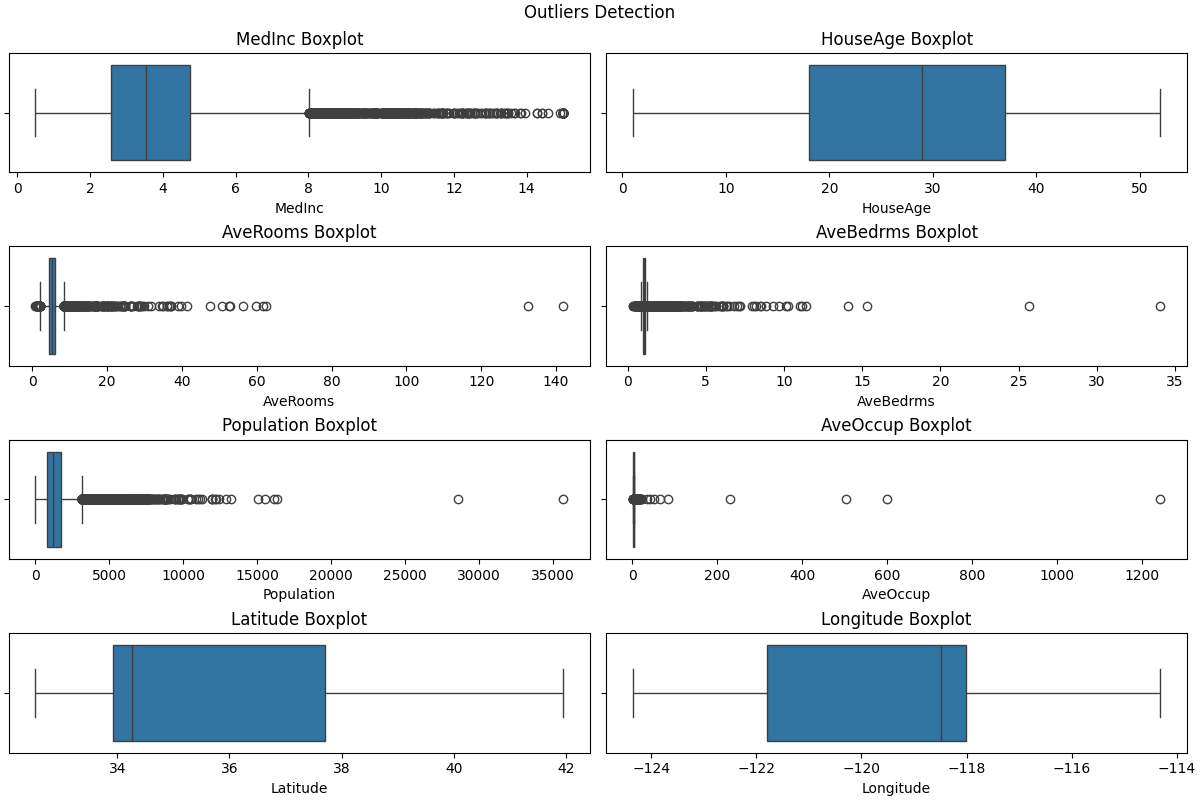

In [9]:
eda.plot_outliers()
plt.show()

## Models

### Linear regression

#### Gauss-Markov assumption

In [10]:
model = get_pipeline(OLS())
model.fit(d.X_train, d.y_train)
y_pred_train = model.predict(d.X_train)
diag = GaussMarkovDiagnostics()

##### Residuals plot

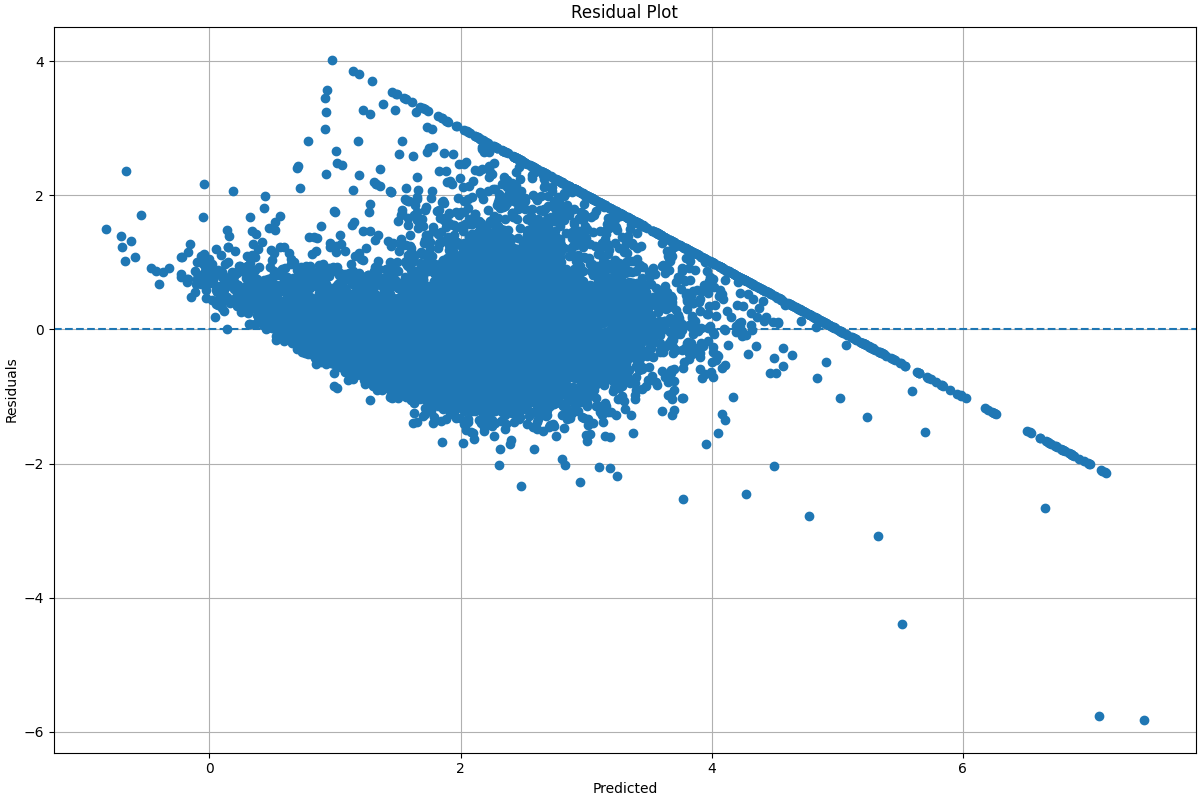

In [11]:
residuals_train = d.y_train - y_pred_train
diag.plot_residuals(d.y_train, y_pred_train)

plt.show()

##### QQ-plot

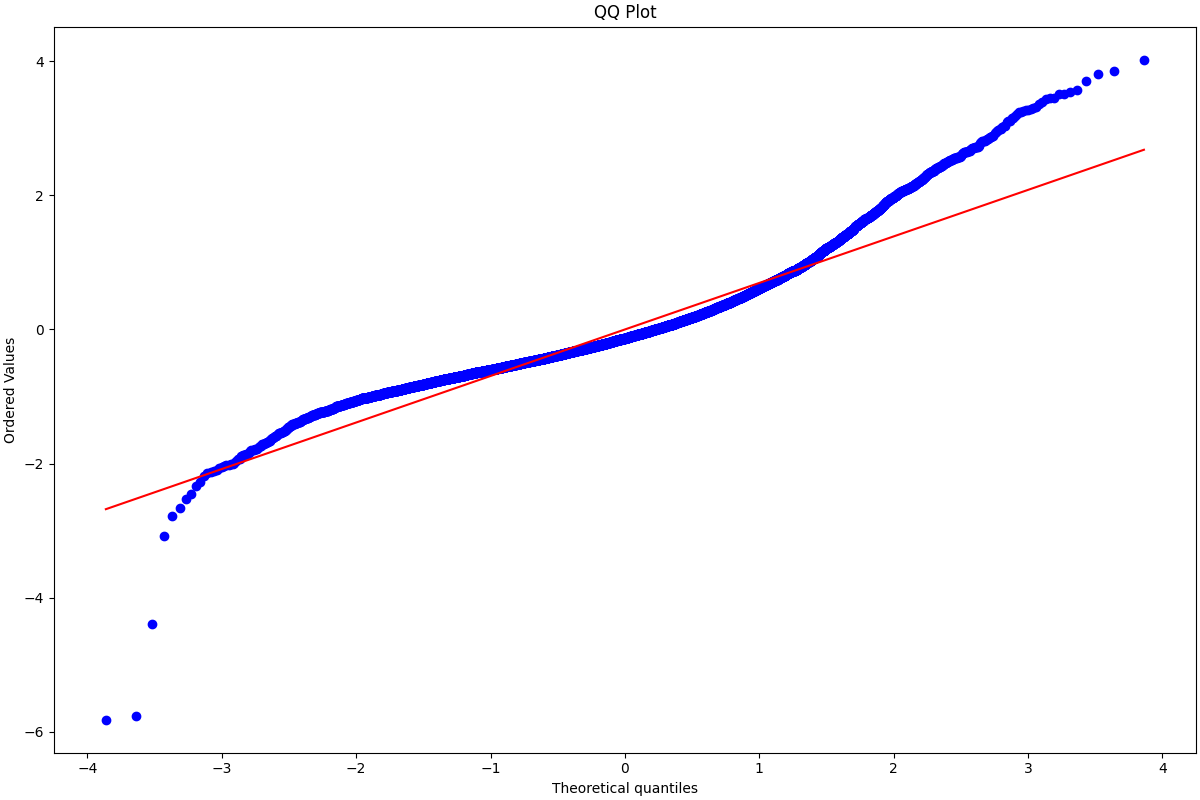

In [12]:
diag.plot_qq(residuals_train)
plt.show()

##### Breusch–Pagan test

In [13]:
result = diag.breusch_pagan_test(d.X_train, residuals_train)
display(result)

{'LM Stat': np.float64(1248.615593028101),
 'LM p-value': np.float64(2.9971092972062764e-264),
 'F Stat': np.float64(173.4517799184423),
 'F p-value': np.float64(1.049113595091813e-278)}

### Regularization and features selecton

#### Ridge Regression

In [5]:
lambdas = np.logspace(-10, 1, 12)

In [6]:
model = get_pipeline(RidgeRegressionCV(alphas=lambdas, cv=10))
model.fit(d.X_train, d.y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('predictor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,alphas,"[np.float64(10.0), np.float64(1.0), ...]"
,cv,10
,random_state,42


In [16]:
print(model.named_steps["predictor"].best_alpha_)

1e-10


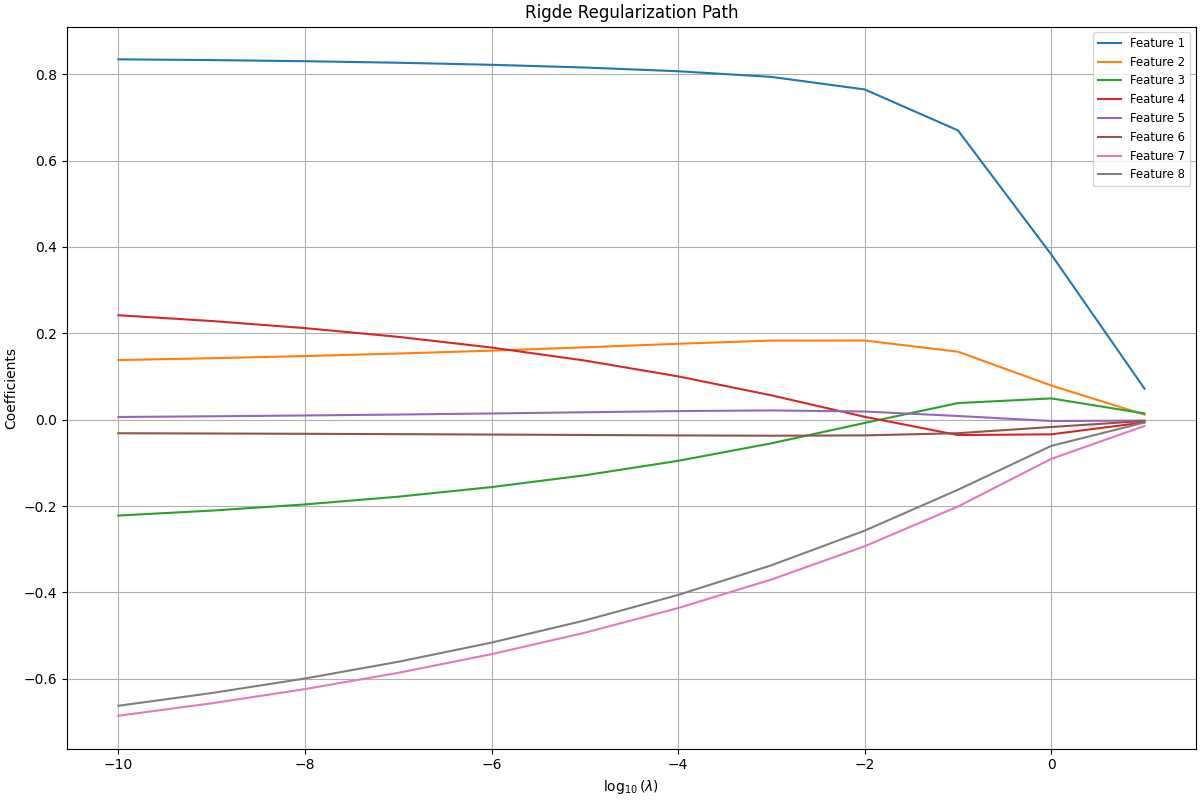

In [17]:
model.named_steps["predictor"].plot_regularization_path(title="Rigde Regularization Path")

#### Lasso Regression

In [7]:
lambdas = np.logspace(-10, 1, 12)

In [8]:
model = get_pipeline(LassoRegressionCV(alphas=lambdas, cv=10))
model.fit(d.X_train, d.y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('predictor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,alphas,"[np.float64(10.0), np.float64(1.0), ...]"
,cv,10
,random_state,42


In [20]:
print(model.named_steps["predictor"].best_alpha_)

1e-10


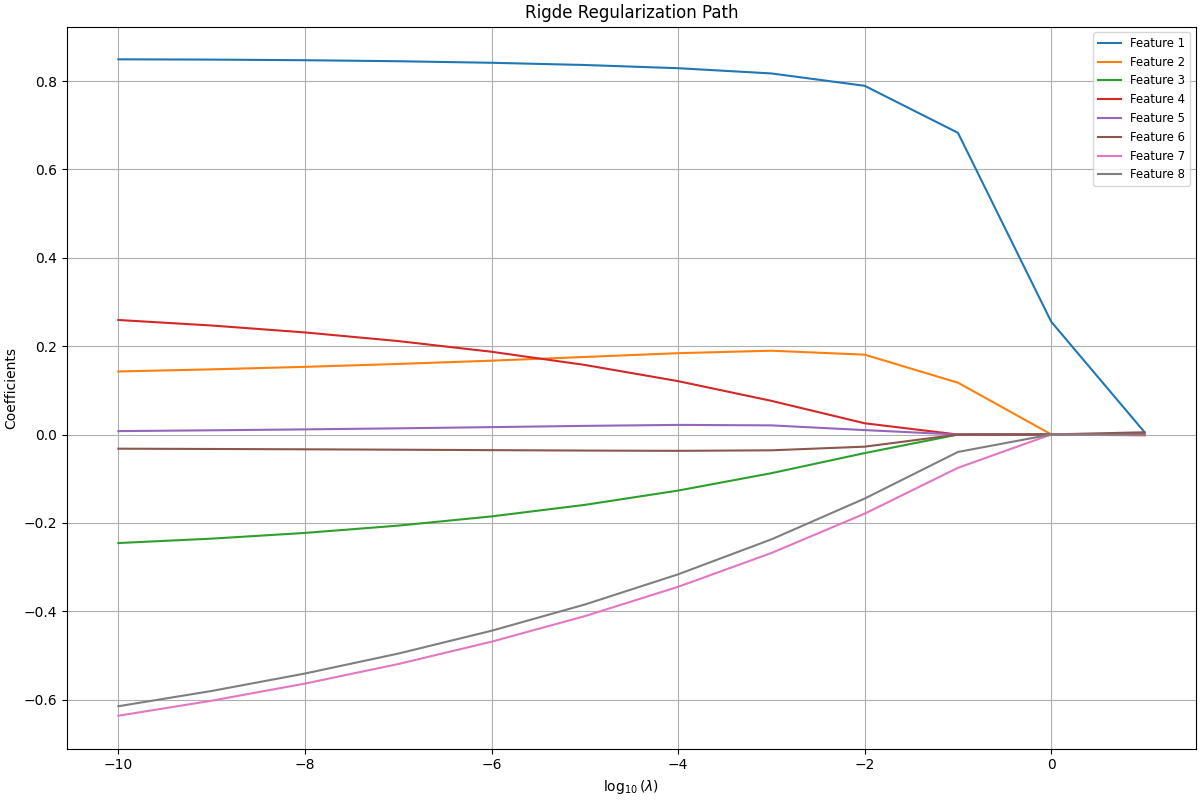

In [21]:
model.named_steps["predictor"].plot_regularization_path(title="Rigde Regularization Path")

#### Elastic Net

In [22]:
lambda_1s = np.logspace(-10, 1, 12)
lambda_2s = np.logspace(-10, 1, 12)

In [23]:
model = get_pipeline(ElasticNetCV(alpha_1s=lambda_1s, alpha_2s=lambda_2s, cv=10))
model.fit(d.X_train, d.y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('predictor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,alpha_1s,"[np.float64(10.0), np.float64(1.0), ...]"
,alpha_2s,"[np.float64(10.0), np.float64(1.0), ...]"
,cv,10
,random_state,42


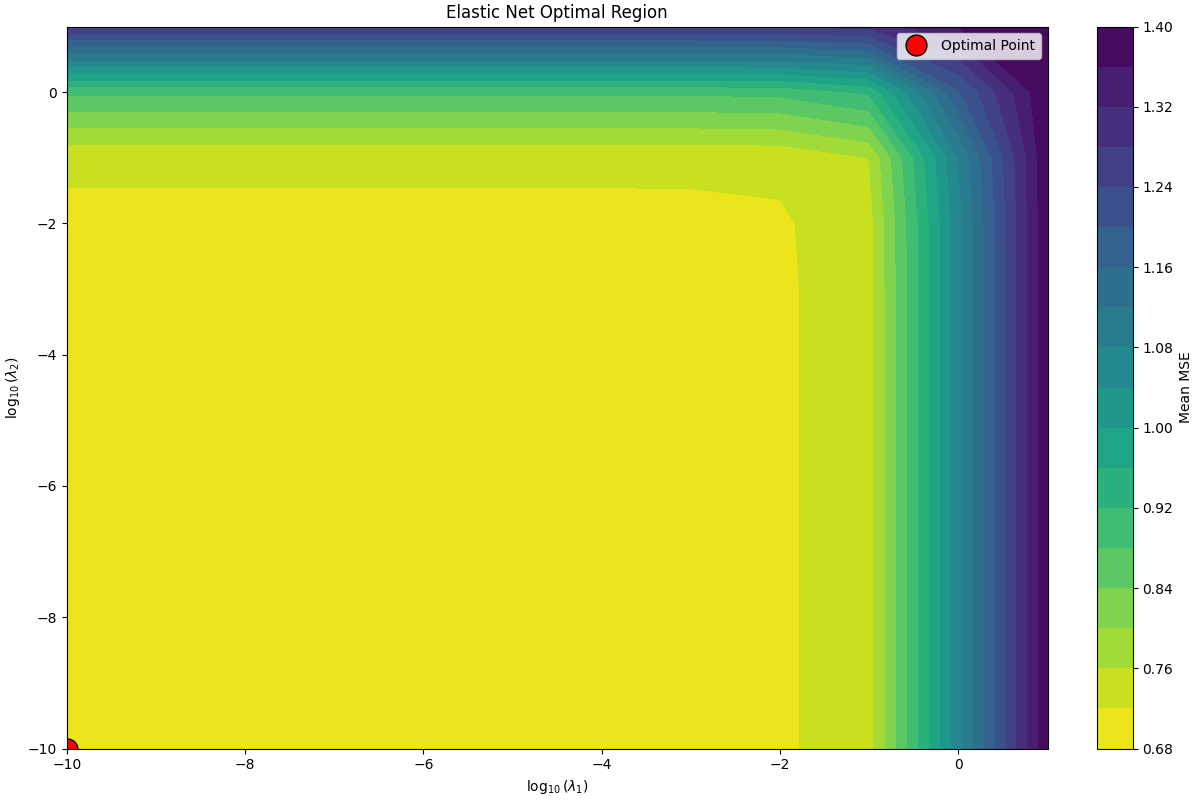

In [24]:
model.named_steps["predictor"].plot_optimal_region(title="Elastic Net Optimal Region")

#### Features Selection

In [25]:
k_features = 'auto'

In [14]:
ols_model = get_pipeline(OLS())
lasso_model = get_pipeline(Lasso())

##### Forward

In [15]:
forward_selection(d.X_train, d.y_train, ols_model, k_features, d.feature_names)

['MedInc', 'HouseAge', 'Latitude', 'Longitude']

In [16]:
forward_selection(d.X_train, d.y_train, lasso_model, k_features, d.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']

##### Backward

In [17]:
backward_elimination(d.X_train, d.y_train, ols_model, k_features, d.feature_names)

['MedInc', 'HouseAge', 'Latitude', 'Longitude']

In [18]:
backward_elimination(d.X_train, d.y_train, lasso_model, k_features, d.feature_names)

['Population', 'AveOccup', 'Latitude', 'Longitude']

##### Lasso

In [19]:
lambdas = np.logspace(-10, 1, 12)

In [20]:
lasso_selection(d.X_train, d.y_train, d.feature_names, alphas=lambdas, cv=10)

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'AveOccup',
 'Latitude',
 'Longitude']

### Non-linear basis and Ablation study

#### Validation Curve

degree=1 → MSE=0.5349
degree=2 → MSE=2.0967
degree=3 → MSE=65.1358
degree=4 → MSE=985.9195
degree=5 → MSE=642335.1990
degree=6 → MSE=990824603.3006
degree=7 → MSE=870914361.8040
degree=8 → MSE=24147262204.6357
degree=9 → MSE=3611468799507.6123
degree=10 → MSE=7751274.7854


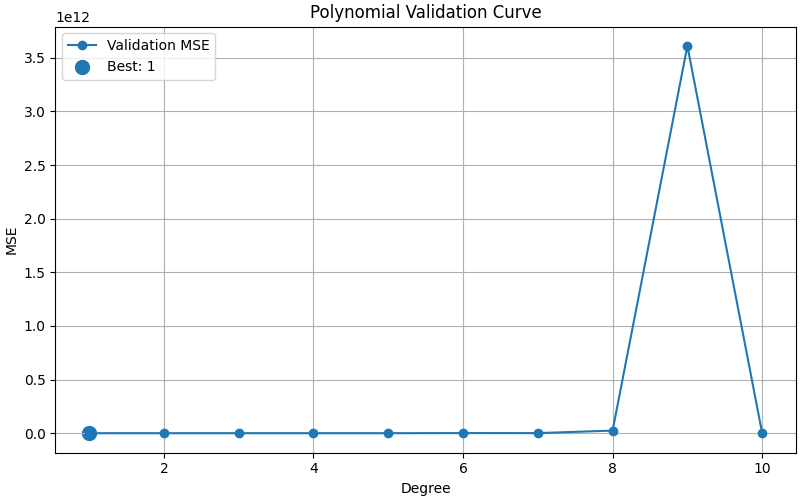

n_centers=5 → MSE=1.0185
n_centers=15 → MSE=0.7012
n_centers=25 → MSE=0.6311
n_centers=35 → MSE=0.5279
n_centers=45 → MSE=0.4929
n_centers=55 → MSE=0.4561
n_centers=65 → MSE=0.4418
n_centers=75 → MSE=0.4185
n_centers=85 → MSE=0.4136
n_centers=95 → MSE=0.3966


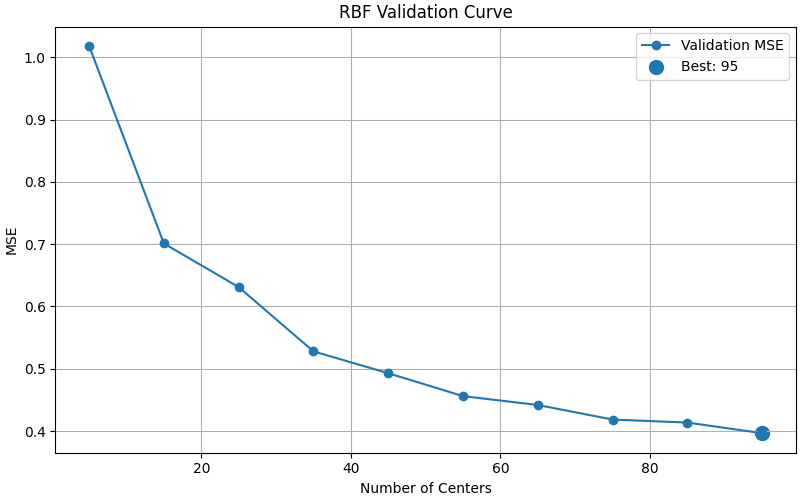

n_terms=1 → MSE=0.5488
n_terms=2 → MSE=0.4482
n_terms=3 → MSE=0.4356
n_terms=4 → MSE=0.4202
n_terms=5 → MSE=0.4199
n_terms=6 → MSE=0.5948
n_terms=7 → MSE=0.6172
n_terms=8 → MSE=10.8597
n_terms=9 → MSE=381.1882
n_terms=10 → MSE=3791.8363


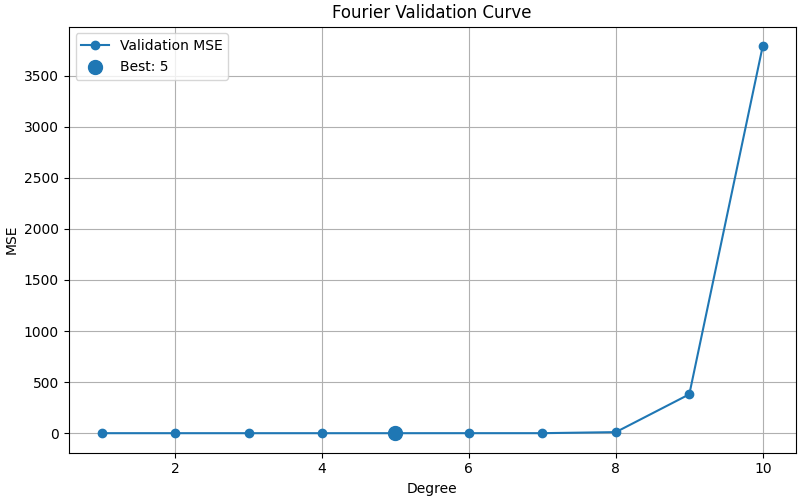

In [2]:
exp = ValidationExperiment()
exp.load_data()
exp.run_all()

Ablation Study


===== VALIDATION ABLATION RESULTS =====
RBF                  : 0.637879
Fourier              : 0.419886
Polynomial           : 65.135821
NO_RBF               : 0.493888
NO_FOURIER           : 1767.324896
NO_POLY              : 0.417499
NO_ECONOMIC          : 255.325352
NO_DENSITY           : 0.442693
NO_SPATIAL           : 605.146135
NO_MedInc            : 807.261046
NO_HouseAge          : 8.008103
NO_AveRooms          : 189.150772
NO_AveBedrms         : 90.545996
NO_Population        : 60.263111
NO_AveOccup          : 0.471775
NO_Latitude          : 187.599768
NO_Longitude         : 161.883225
FULL                 : 78.553132


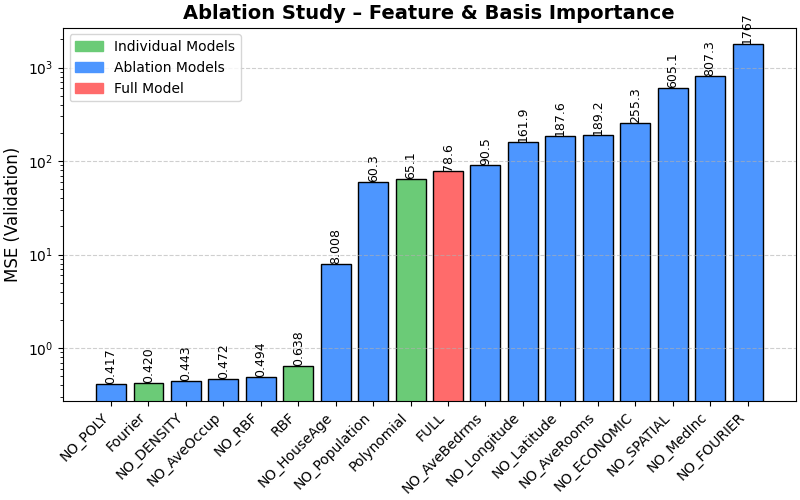

In [2]:
exp = AblationStudy()
exp.run_all()
exp.print_results()
exp.plot()


===== FEATURE RANKING (ΔMSE) =====
NO_FOURIER           : 1688.771764
NO_MedInc            : 728.707915
NO_SPATIAL           : 526.593003
NO_ECONOMIC          : 176.772220
NO_AveRooms          : 110.597641
NO_Latitude          : 109.046636
NO_Longitude         : 83.330093
NO_AveBedrms         : 11.992864
NO_Population        : -18.290021
NO_HouseAge          : -70.545029
NO_RBF               : -78.059244
NO_AveOccup          : -78.081357
NO_DENSITY           : -78.110439
NO_POLY              : -78.135632


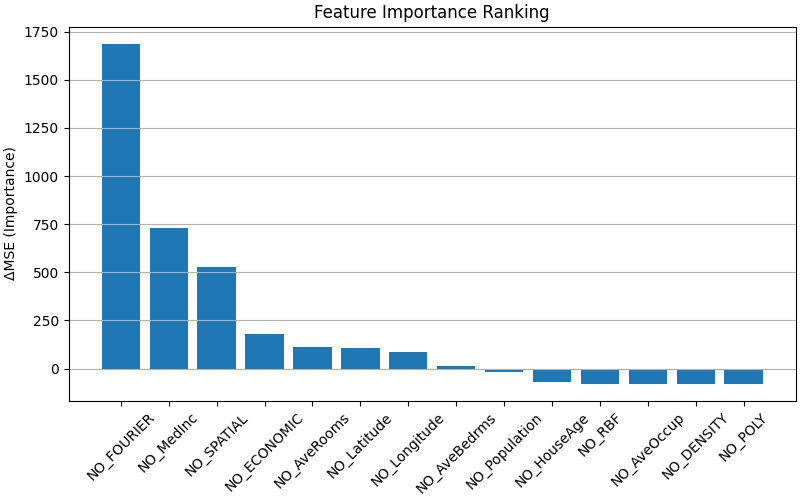

In [3]:
exp.rank_features() 
exp.plot_importance()

#### Interaction

In [12]:
X_train, y_train = d.X_train, d.y_train
X_val, y_val = d.X_val, d.y_val

y_train = y_train.ravel()
y_val = y_val.ravel()

# ===== MODEL WITH INTERACTION =====
model_inter = get_pipeline(
    predictor=LinearRegression(),
    features=None,
    use_interaction=True
)

model_inter.fit(X_train, y_train)
y_pred_inter = model_inter.predict(X_val)

mse_inter = mean_squared_error(y_val, y_pred_inter)
print("MSE (with interaction):", mse_inter)


MSE (with interaction): 4.012430981538565


In [13]:
model_base = get_pipeline(
    predictor=LinearRegression(),
    features=PolynomialBasis(degree=2),
    use_interaction=False
)

model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_val)

mse_base = mean_squared_error(y_val, y_pred_base)
print("MSE (no interaction):", mse_base)

print("Improvement:", mse_base - mse_inter)

MSE (no interaction): 2.096747042719358
Improvement: -1.9156839388192073


## Advanced

### Bayesian Regression


In [10]:
# ===== MODEL =====
X_train, y_train = d.X_train, d.y_train
X_test, y_test = d.X_test, d.y_test
model = BayesianLinearRegression(alpha=1.0, beta=10.0)
model.fit(X_train, y_train)


,alpha,1.0
,beta,10.0


In [11]:
 # ===== POSTERIOR =====
m_N, S_N = model.get_posterior()
print("Posterior mean shape:", m_N.shape)
print("Posterior covariance shape:", S_N.shape)

Posterior mean shape: (9, 1)
Posterior covariance shape: (9, 9)


In [12]:
 # ===== PREDICT =====
y_mean, y_std = model.predict_dist(X_test)
mse = np.mean((y_test - y_mean) ** 2)
print(f"MSE = {mse:.6f}")

MSE = 0.524602


In [ ]:
# ===== PLOT (1D visualization) =====
X_plot = X_test[:, 0]
idx = np.argsort(X_plot)

plt.figure(figsize=(8, 5))

# data test
plt.scatter(X_plot, y_test, s=10, label="Test data")

# mean prediction
plt.plot(X_plot[idx], y_mean[idx], label="Mean")

# vùng bất định ±2σ
plt.fill_between(
    X_plot[idx],
    y_mean[idx] - 2*y_std[idx],
    y_mean[idx] + 2*y_std[idx],
    alpha=0.3,
    label="±2σ"
)
plt.xlabel("Median Income (MedInc) - Feature 0")
plt.ylabel("House Price (Target)")
plt.legend()
plt.title("Bayesian Linear Regression (Uncertainty)")
plt.show()


In [14]:
#Optimazation alpha , beta using Evidence Maximization to compare with CV 
start = time.time()

model_em = BayesianLinearRegression()
model_em.evidence_maximization(X_train, y_train)

y_pred_em = model_em.predict(X_test)

em_time = time.time() - start
em_mse = mean_squared_error(y_test, y_pred_em)

#  CV 
param_grid = {
    "alpha": [0.1, 1, 10],
    "beta": [1, 10, 100]
}

start = time.time()

grid = GridSearchCV(
    BayesianLinearRegression(),
    param_grid,
    cv=3
)
grid.fit(X_train, y_train)

y_pred_cv = grid.predict(X_test)

cv_time = time.time() - start
cv_mse = mean_squared_error(y_test, y_pred_cv)

# ================= RESULT =================
print("\n===== EVIDENCE MAXIMIZATION =====")
print("alpha:", model_em.alpha)
print("beta:", model_em.beta)
print("MSE:", em_mse)
print("Time:", em_time)

print("\n===== CROSS VALIDATION =====")
print("Best params:", grid.best_params_)
print("MSE:", cv_mse)
print("Time:", cv_time)

print("\n===== COMPARISON =====")
print(f"EM faster than CV? {em_time < cv_time}")
print(f"EM better MSE than CV? {em_mse < cv_mse}")


===== EVIDENCE MAXIMIZATION =====
alpha: 0.00642935297260498
beta: 1.9166775717921143
MSE: 0.5252559397234683
Time: 0.03204464912414551

===== CROSS VALIDATION =====
Best params: {'alpha': 0.1, 'beta': 100}
MSE: 0.5253081487281586
Time: 0.10799956321716309

===== COMPARISON =====
EM faster than CV? True
EM better MSE than CV? True


#### Kernel Ridge Regression

In [15]:
models = {
    "Ridge": get_pipeline(RidgeRegression()),
    "RBF Ridge": get_pipeline(KernelRidgeCV(kernel='rbf', cv=2)),
    "Polynomial Ridge": get_pipeline(KernelRidgeCV(kernel='polynomial', cv=2))
}
evaluator = Evaluator()

result = evaluator.compare_models_cv(models, d.X_train, d.y_train)

print(result)

result = evaluator.compare_models_test(models, d.X_train, d.y_train,
                                       d.X_test, d.y_test)
print(result)

stat_result = evaluator.compare_models_statistical(
    models,
    d.X_train,
    d.y_train
)

print(stat_result)

              Model               MSE             RMSE              MAE  \
0             Ridge   0.8875 ± 0.0352  0.9419 ± 0.0186  0.6829 ± 0.0163   
1         RBF Ridge   0.3583 ± 0.0275  0.5982 ± 0.0224  0.4185 ± 0.0098   
2  Polynomial Ridge  4.2643 ± 10.9304  1.2859 ± 1.6158  0.5499 ± 0.2425   

                 R2  
0   0.3288 ± 0.0244  
1   0.7289 ± 0.0210  
2  -2.4059 ± 8.7993  
              Model       MSE      RMSE       MAE        R2
0             Ridge  0.895142  0.946120  0.680719  0.335008
1         RBF Ridge  0.357096  0.597575  0.417524  0.734717
2  Polynomial Ridge  0.434008  0.658793  0.466575  0.677580
     Model A           Model B  p-value (t-test)  p-value (Wilcoxon)
0      Ridge         RBF Ridge      1.998716e-13            0.001953
1      Ridge  Polynomial Ridge      3.789153e-01            0.431641
2  RBF Ridge  Polynomial Ridge      3.117077e-01            0.001953


### Gaussian Process Regression

In [24]:
rng = np.random.default_rng(42)
idx = rng.choice(len(d.X_train), 2000, replace=False)
X_sub = d.X_train[idx]
y_sub = d.y_train[idx]

model = get_pipeline(GPR())
model.fit(X_sub, y_sub)

y_pred, y_std = model.predict(d.X_train)
y_true = d.y_train
print("min std:", y_std.min())
print("max std:", y_std.max())

/home/quihoang/Projects/supervised-learning-project/.venv/lib64/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


min std: 2.6375261718730796
max std: 3.0450061851458416


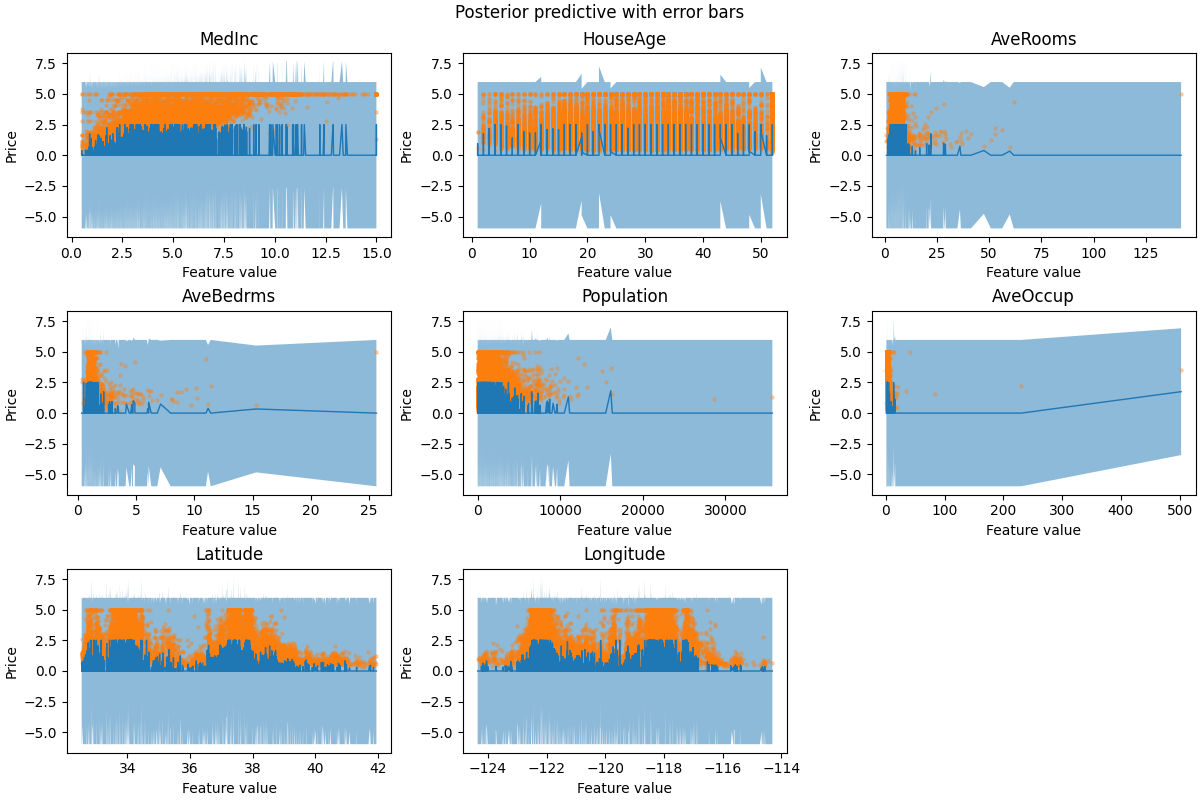

In [37]:
feature_names = getattr(d, "feature_names", [f"Feature {i}" for i in range(d.X.shape[1])])

n_features = d.X.shape[1]

fig, axes = plt.subplots(3, 3)
axes = axes.flatten()
for i in range(n_features):
    x_plot = d.X_train[:, i]
    idx = np.argsort(x_plot)

    axes[i].plot(x_plot[idx], y_pred[idx], label="Pred", linewidth=1)

    # Uncertainty band
    axes[i].fill_between(
        x_plot[idx],
        y_pred[idx] - 1.96 * y_std[idx],
        y_pred[idx] + 1.96 * y_std[idx],
        alpha=0.5
    )

    # True points
    axes[i].scatter(x_plot, y_true, s=5, alpha=0.3)

    axes[i].set_title(feature_names[i])
    axes[i].set_xlabel("Feature value")
    axes[i].set_ylabel("Price")

axes[8].axis("off")
fig.suptitle("Posterior predictive with error bars")
plt.show()

### Robust Regression

In [18]:
huber = get_pipeline(IRLS(loss="huber"))
huber.fit(d.X_train, d.y_train)
y_pred_huber = huber.predict(d.X_test)

student = get_pipeline(IRLS(loss="student-t"))
student.fit(d.X_train, d.y_train)
y_pred_student = student.predict(d.X_test)

model_ols = get_pipeline(OLS())
model_ols.fit(d.X_train, d.y_train)
y_pred_ols = model_ols.predict(d.X_test)

y_true = d.y_test

print("=== Overall MSE ===")
print(f"OLS: {mean_squared_error(y_true, y_pred_ols):.4f}")
print(f"Huber IRLS: {mean_squared_error(y_true, y_pred_huber):.4f}")
print(f"Student-t IRLS: {mean_squared_error(y_true, y_pred_student):.4f}")

=== Overall MSE ===
OLS: 0.5253
Huber IRLS: 0.5180
Student-t IRLS: 0.4726


In [19]:
def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mae, r2


def outlier_sensitivity_df(models, data, outlier_ratio=0.1, noise_scale=5.0):
    rows = []

    # ===== CLEAN TRAIN =====
    clean_scores = {}

    for name, model in models.items():
        model.fit(data.X_train, data.y_train)
        y_pred = model.predict(data.X_test)

        mse, rmse, mae, r2 = compute_metrics(data.y_test, y_pred)
        clean_scores[name] = (mse, rmse, mae, r2)

    # ===== ADD OUTLIERS =====
    y_train_noisy = data.y_train.copy()

    idx = np.random.choice(
        len(y_train_noisy),
        int(outlier_ratio * len(y_train_noisy)),
        replace=False
    )

    y_train_noisy[idx] += noise_scale * np.std(y_train_noisy)

    # ===== NOISY TRAIN =====
    noisy_scores = {}

    for name, model in models.items():
        model.fit(data.X_train, y_train_noisy)
        y_pred = model.predict(data.X_test)

        mse, rmse, mae, r2 = compute_metrics(data.y_test, y_pred)
        noisy_scores[name] = (mse, rmse, mae, r2)

    # ===== BUILD DATAFRAME =====
    for name in models.keys():
        cmse, crmse, cmae, cr2 = clean_scores[name]
        nmse, nrmse, nmae, nr2 = noisy_scores[name]

        rows.append({
            "Model": name,

            "MSE_clean": cmse,
            "MSE_noisy": nmse,
            "MSE_sensitivity": (nmse - cmse) / (cmse + 1e-8),

            "RMSE_clean": crmse,
            "RMSE_noisy": nrmse,
            "RMSE_sensitivity": (nrmse - crmse) / (crmse + 1e-8),

            "MAE_clean": cmae,
            "MAE_noisy": nmae,
            "MAE_sensitivity": (nmae - cmae) / (cmae + 1e-8),

            "R2_clean": cr2,
            "R2_noisy": nr2,
            "R2_sensitivity": (cr2 - nr2),
        })

    return pd.DataFrame(rows)

models = {
    "OLS": get_pipeline(OLS()),
    "IRLS (Huber)": get_pipeline(IRLS(loss="huber")),
    "IRLS (Student-t)": get_pipeline(IRLS(loss="student-t")),
}

df = outlier_sensitivity_df(models, d)
# df.round(4).to_csv("regression-irls-outliers-sensitivity.csv", index=False)

display(df)

,Model,MSE_clean,MSE_noisy,MSE_sensitivity,RMSE_clean,RMSE_noisy,RMSE_sensitivity,MAE_clean,MAE_noisy,MAE_sensitivity,R2_clean,R2_noisy,R2_sensitivity
0,OLS,0.525331,0.861938,0.640752,0.724797,0.928406,0.280918,0.529916,0.796649,0.503348,0.609737,0.359676,0.250062
1,IRLS (Huber),0.518014,0.525928,0.015279,0.719732,0.725209,0.007610,0.512925,0.539434,0.051682,0.615173,0.609293,0.005880
2,IRLS (Student-t),0.472567,0.474802,0.004730,0.687435,0.689059,0.002362,0.490149,0.504871,0.030036,0.648935,0.647275,0.001661


### Bias-Variance Analysis

##### Ridge 

In [20]:
model = get_pipeline(BiasVarianceAnalyzer(estimator=Ridge()))
model.fit(d.X_train, d.y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('predictor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,estimator,Ridge()
,n_bootstrap,200
,random_state,42
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0


(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Bias–Variance vs Regularization Path'}, xlabel='$log_{10}(\\lambda)$', ylabel='Error'>)

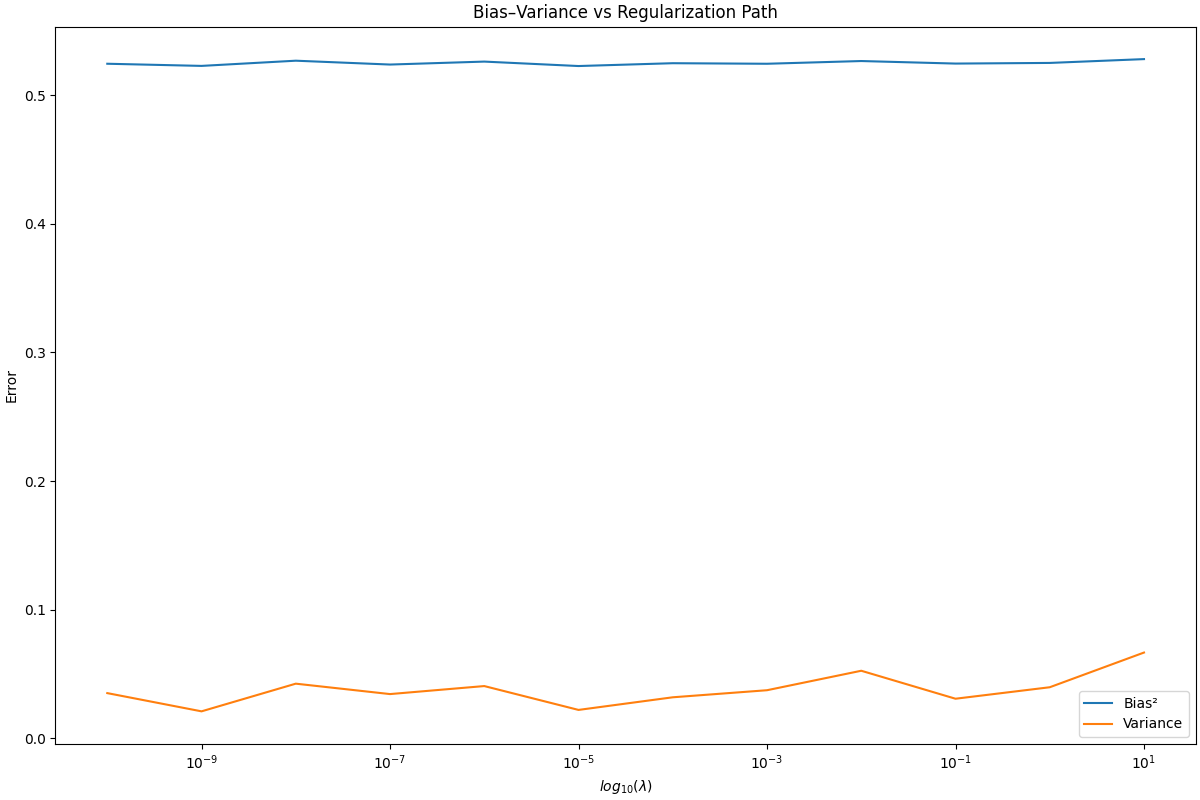

In [21]:
model.named_steps["predictor"].plot()

In [22]:
model = get_pipeline(BiasVarianceAnalyzer(estimator=Lasso()))
model.fit(d.X_train, d.y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('predictor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,estimator,Lasso()
,n_bootstrap,200
,random_state,42
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0


In [23]:
model.named_steps["predictor"].plot()

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Bias–Variance vs Regularization Path'}, xlabel='$log_{10}(\\lambda)$', ylabel='Error'>)

## Evaluation

In [3]:
logger = get_logger("logger", "log.txt")
# logger = None

In [4]:
models = {
    "OLS": get_pipeline(OLS()),
    "MBGD": get_pipeline(MBGD(lr_sched="step_decay")),
    "WLS": get_pipeline(WLS()),
    "Ridge": get_pipeline(get_pipeline(RidgeRegressionCV()).fit(d.X_train, d.y_train).named_steps["predictor"].final_model_),
    "Lasso": get_pipeline(get_pipeline(LassoRegressionCV()).fit(d.X_train, d.y_train).named_steps["predictor"].final_model_),
    "Elastic Net": get_pipeline(get_pipeline(ElasticNetCV()).fit(d.X_train, d.y_train).named_steps["predictor"].final_model_),
    "Polynomial": get_pipeline(OLS(), PolynomialBasis(degree=2)),
    "RBF": get_pipeline(OLS(), RBF(n_centers=10, gamma=0.1)),
    "Fourier": get_pipeline(OLS(), FourierBasis(n_terms=5))
}

### Evaluate on test set, cross-validation, t-test, Wilcoxon signed-rank test

In [5]:
evaluator = Evaluator(logger=logger, log_model=True)

#### On test set

In [6]:
result = evaluator.compare_models_test(models, d.X_train, d.y_train,
                                       d.X_test, d.y_test)
# result.round(4).to_csv("regression-models-test.csv", index=False)
print("===Test Result===")
display(result)

===Test Result===


,Model,MSE,RMSE,MAE,R2
0,OLS,0.525331,0.724797,0.529916,0.609737
1,MBGD,0.525415,0.724855,0.529913,0.609674
2,WLS,0.527603,0.726363,0.520482,0.608049
3,Ridge,0.729670,0.854207,0.595350,0.457936
4,Lasso,0.747721,0.864709,0.605148,0.444526
5,Elastic Net,0.766020,0.875225,0.615269,0.430932
6,Polynomial,0.494023,0.702868,0.514549,0.632996
7,RBF,0.697130,0.834943,0.627836,0.482110
8,Fourier,0.387296,0.622331,0.446559,0.712282


#### Cross-validation

In [7]:
result = evaluator.compare_models_cv(models, d.X_train, d.y_train)
# result.to_csv("regression-models-cv.csv", index=False)

print("===Cross-validate result===")
display(result)

===Cross-validate result===


,Model,MSE,RMSE,MAE,R2
0,OLS,0.5345 ± 0.0384,0.7306 ± 0.0256,0.5315 ± 0.0068,0.5961 ± 0.0237
1,MBGD,0.5344 ± 0.0382,0.7306 ± 0.0255,0.5316 ± 0.0068,0.5961 ± 0.0235
2,WLS,0.6220 ± 0.1587,0.7829 ± 0.0953,0.5263 ± 0.0088,0.5287 ± 0.1230
3,Ridge,0.7263 ± 0.0328,0.8520 ± 0.0191,0.5972 ± 0.0149,0.4504 ± 0.0295
4,Lasso,0.7431 ± 0.0310,0.8618 ± 0.0179,0.6056 ± 0.0147,0.4378 ± 0.0271
5,Elastic Net,0.7608 ± 0.0313,0.8721 ± 0.0178,0.6158 ± 0.0151,0.4244 ± 0.0265
6,Polynomial,0.6877 ± 0.5260,0.7943 ± 0.2383,0.5201 ± 0.0120,0.4853 ± 0.3738
7,RBF,0.7295 ± 0.0219,0.8540 ± 0.0128,0.6524 ± 0.0133,0.4479 ± 0.0249
8,Fourier,1.0607 ± 2.0013,0.8303 ± 0.6093,0.4597 ± 0.0270,0.2262 ± 1.4222


#### Test on MSE

In [8]:
stat_result = evaluator.compare_models_statistical(
    models,
    d.X_train,
    d.y_train,
    scoring="neg_mean_squared_error"
)
# stat_result.round(4).to_csv("regression-stat-tests-mse.csv", index=False)
print("===MSE test===")
display(stat_result)

===MSE test===


,Model A,Model B,p-value (t-test),p-value (Wilcoxon)
0,OLS,MBGD,8.750598e-01,0.921875
1,OLS,WLS,7.813112e-02,0.064453
2,OLS,Ridge,1.315798e-06,0.001953
3,OLS,Lasso,5.214217e-07,0.001953
4,OLS,Elastic Net,2.149158e-07,0.001953
5,OLS,Polynomial,3.746498e-01,0.625000
6,OLS,RBF,8.711911e-07,0.001953
7,OLS,Fourier,4.487288e-01,0.083984
8,MBGD,WLS,7.860186e-02,0.083984
9,MBGD,Ridge,1.260714e-06,0.001953


#### Test on MAE

In [9]:
stat_result = evaluator.compare_models_statistical(
    models,
    d.X_train,
    d.y_train,
    scoring="neg_mean_absolute_error"
)
# stat_result.round(4).to_csv("regression-stat-tests-mae", index=False)
print("===MAE test===")
display(stat_result)

===MAE test===


,Model A,Model B,p-value (t-test),p-value (Wilcoxon)
0,OLS,MBGD,2.349595e-01,0.232422
1,OLS,WLS,2.505683e-02,0.037109
2,OLS,Ridge,4.700179e-08,0.001953
3,OLS,Lasso,1.608682e-08,0.001953
4,OLS,Elastic Net,6.106149e-09,0.001953
5,OLS,Polynomial,1.314348e-02,0.037109
6,OLS,RBF,3.664756e-09,0.001953
7,OLS,Fourier,3.929934e-06,0.001953
8,MBGD,WLS,2.529498e-02,0.037109
9,MBGD,Ridge,4.590405e-08,0.001953


### Visualize

In [10]:
visualizer = Visualizer()

#### Learning curves

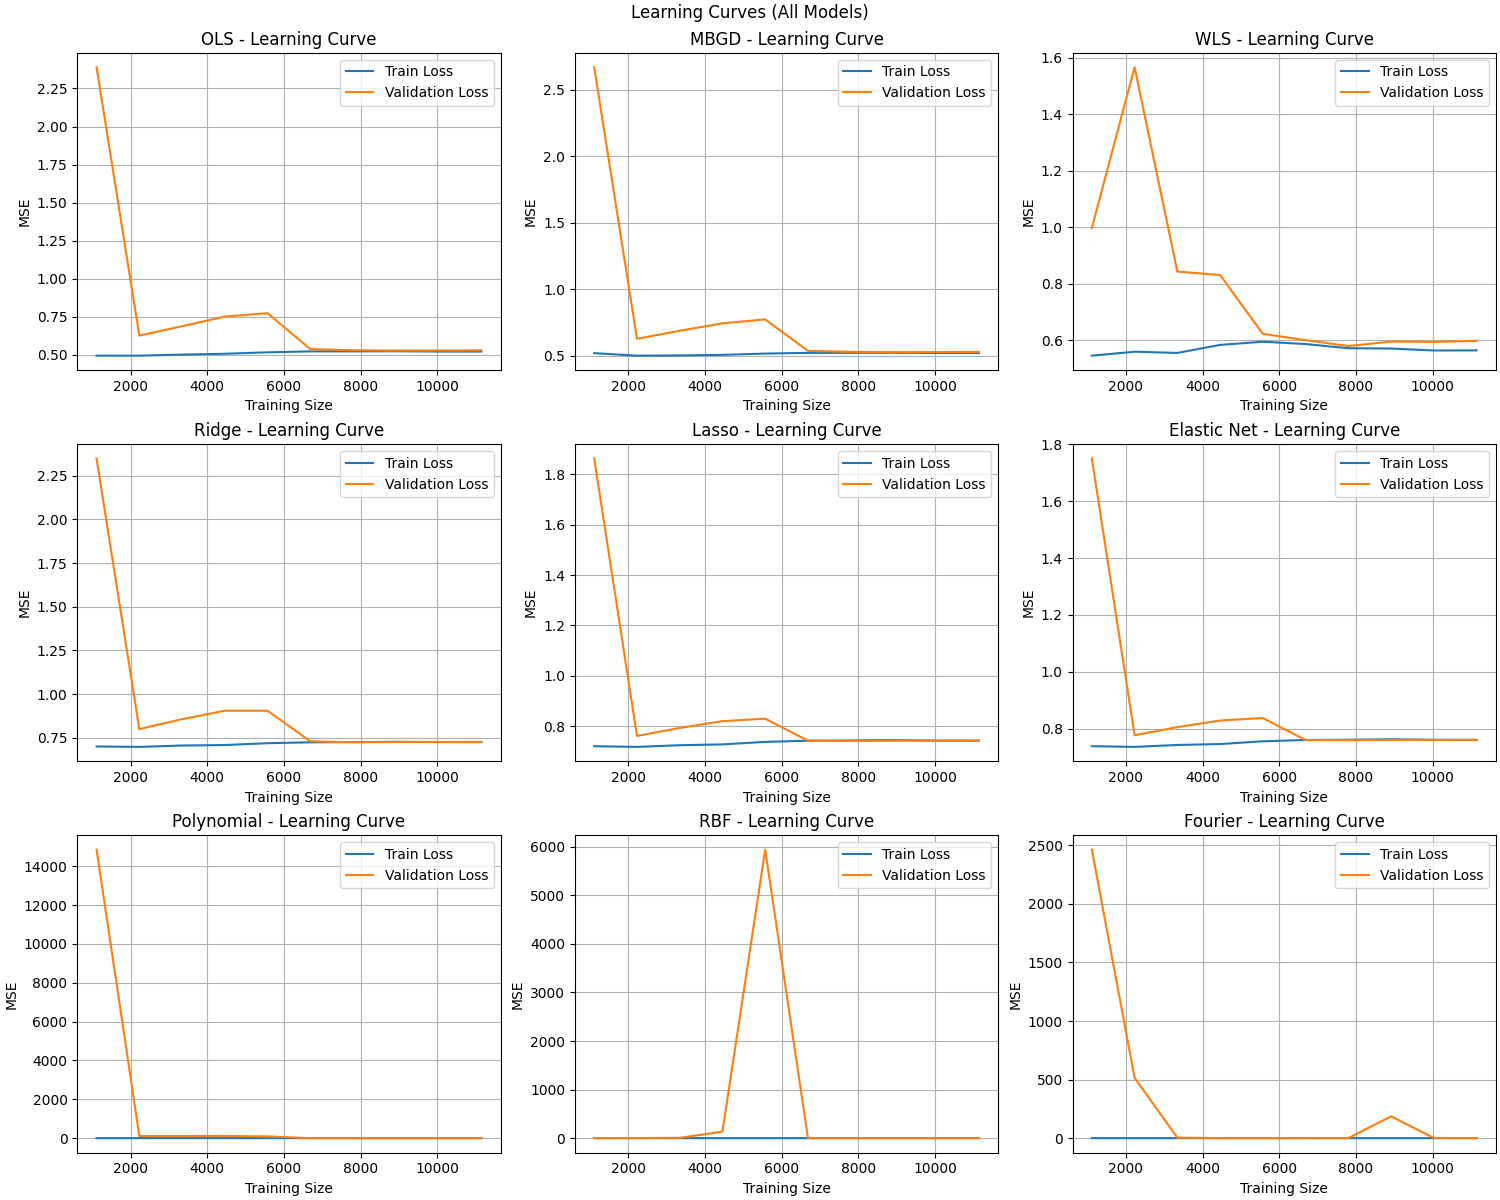

In [11]:
n_models = len(models)

n_cols = 3
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), layout="constrained")
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]

    visualizer.plot_learning_curve(
        model,
        d.X_train,
        d.y_train,
        ax=ax,
        cv=10
    )
    ax.set_title(f"{name} - Learning Curve")

# Ẩn subplot dư
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Learning Curves (All Models)")
plt.show()

#### Residuals plots

In [12]:
for name, model in models.items():
    model.fit(d.X_train, d.y_train)

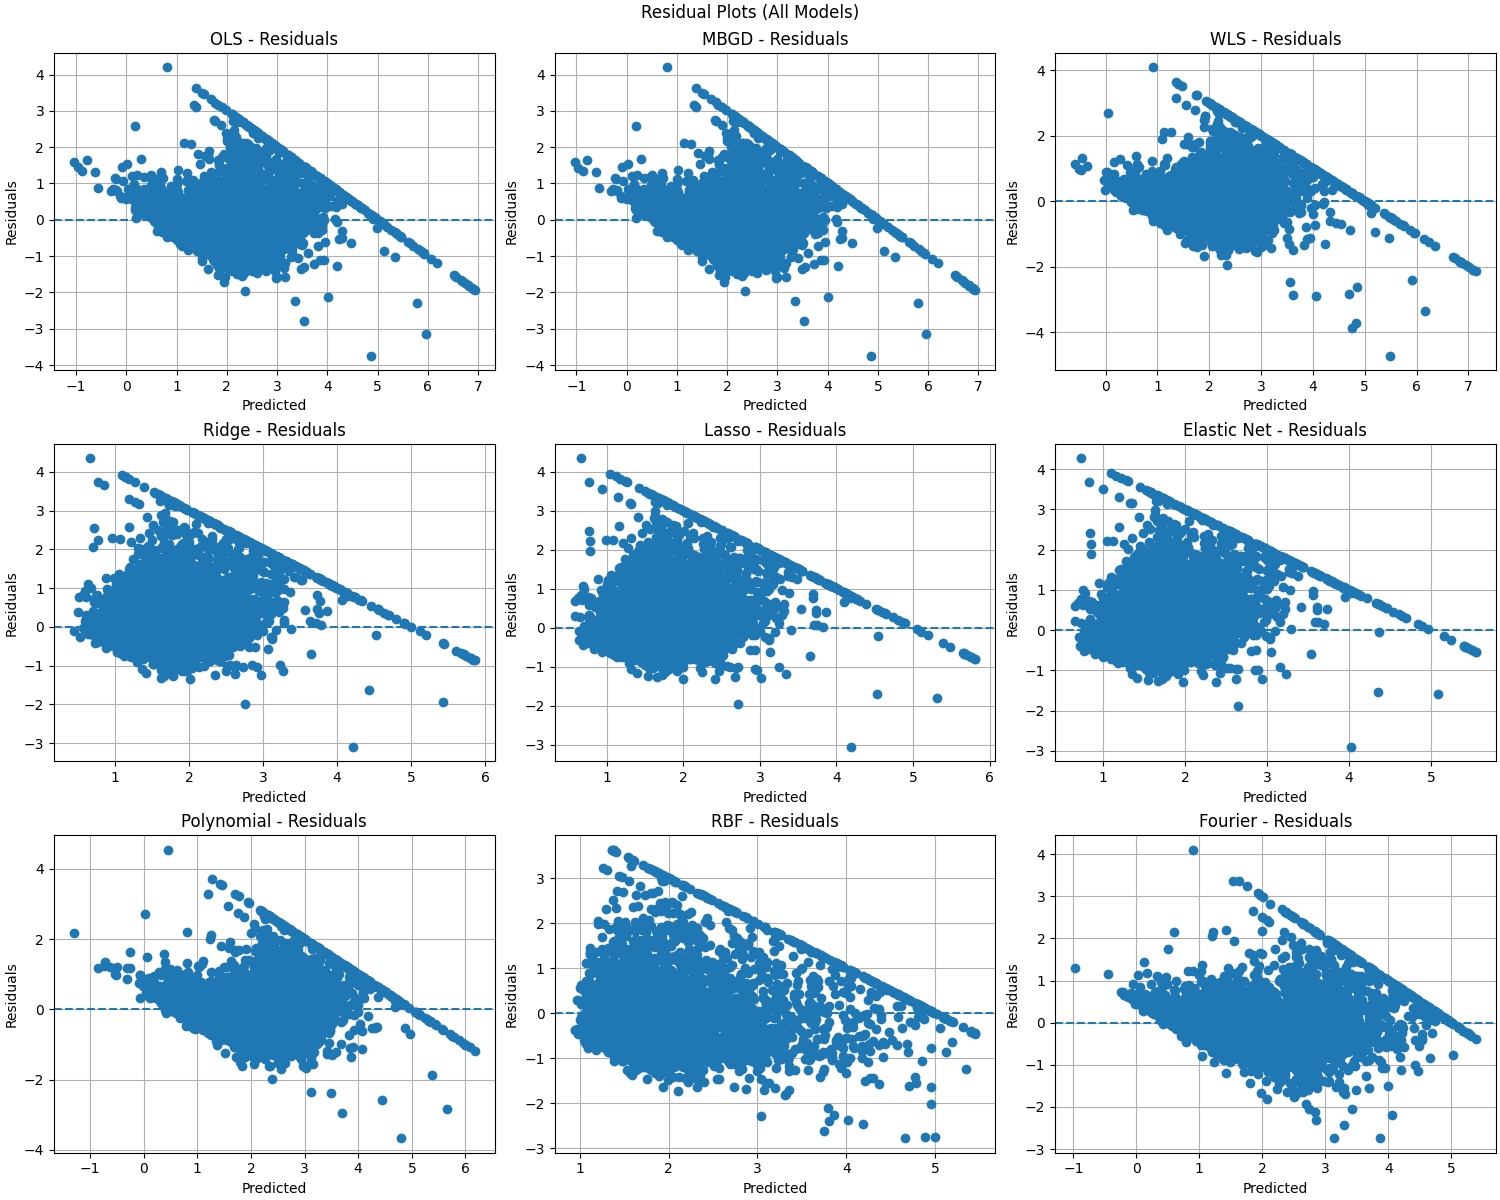

In [13]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), layout="constrained")
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]

    y_pred = model.predict(d.X_test)

    visualizer.plot_residuals(
        d.y_test,
        y_pred,
        ax=ax
    )
    ax.set_title(f"{name} - Residuals")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Residual Plots (All Models)")
plt.show()

#### Predicted-Actual plots

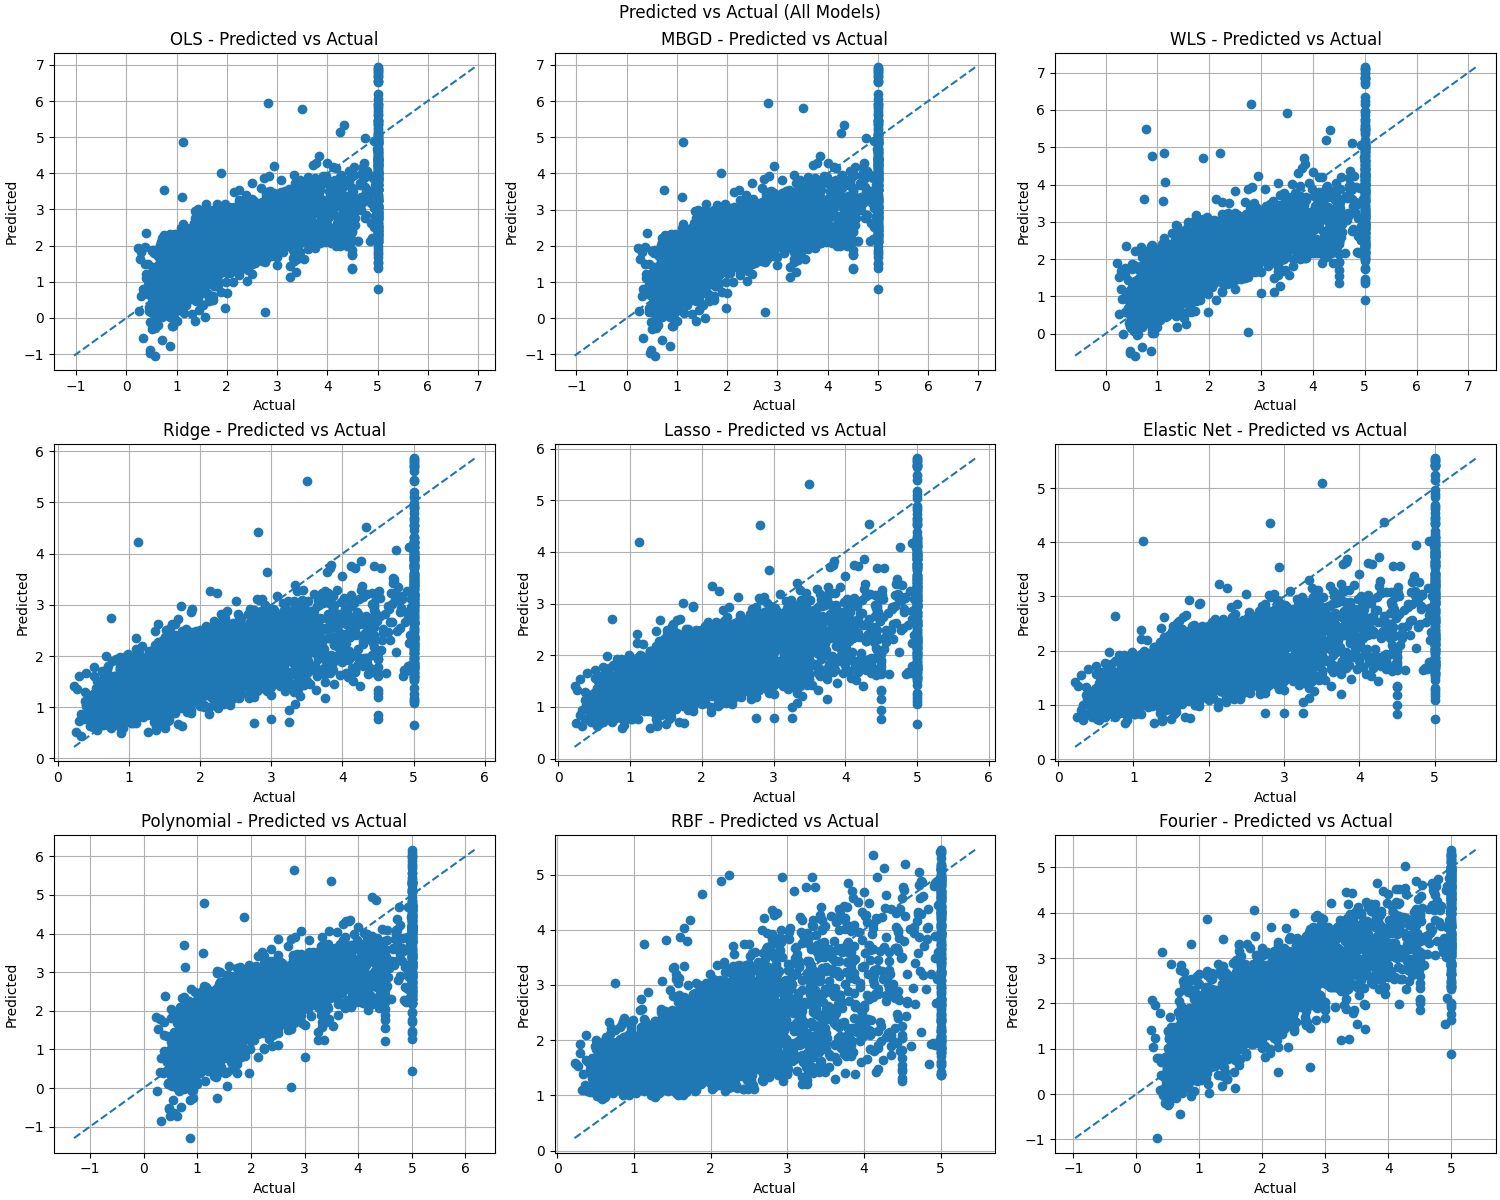

In [14]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), layout="constrained")
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]

    y_pred = model.predict(d.X_test)

    visualizer.plot_pred_vs_actual(
        d.y_test,
        y_pred,
        ax=ax
    )
    ax.set_title(f"{name} - Predicted vs Actual")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Predicted vs Actual (All Models)")
plt.show()

### Sensitivity & Robustness

#### Split sensitivity

In [15]:
df = sensitivity_split_analysis(models, copy.deepcopy(d), task="regression")
# df.round(4).to_csv("regression-sensitivity-split.csv", index=False)
display(df)

,model,split,seed,mse,rmse,mae,r2
0,OLS,60/40,383329927,0.537094,0.732867,0.528066,0.597936
1,MBGD,60/40,383329927,0.537145,0.732902,0.528054,0.597898
2,WLS,60/40,383329927,0.581757,0.762730,0.525479,0.564502
3,Ridge,60/40,383329927,0.730843,0.854894,0.599106,0.452897
4,Lasso,60/40,383329927,0.747263,0.864444,0.606995,0.440606
...,...,...,...,...,...,...,...
265,Lasso,80/20,1904449481,0.809111,0.899506,0.625324,0.409906
266,Elastic Net,80/20,1904449481,0.827224,0.909518,0.635595,0.396696
267,Polynomial,80/20,1904449481,0.841337,0.917244,0.539934,0.386403
268,RBF,80/20,1904449481,0.795880,0.892121,0.674723,0.419556


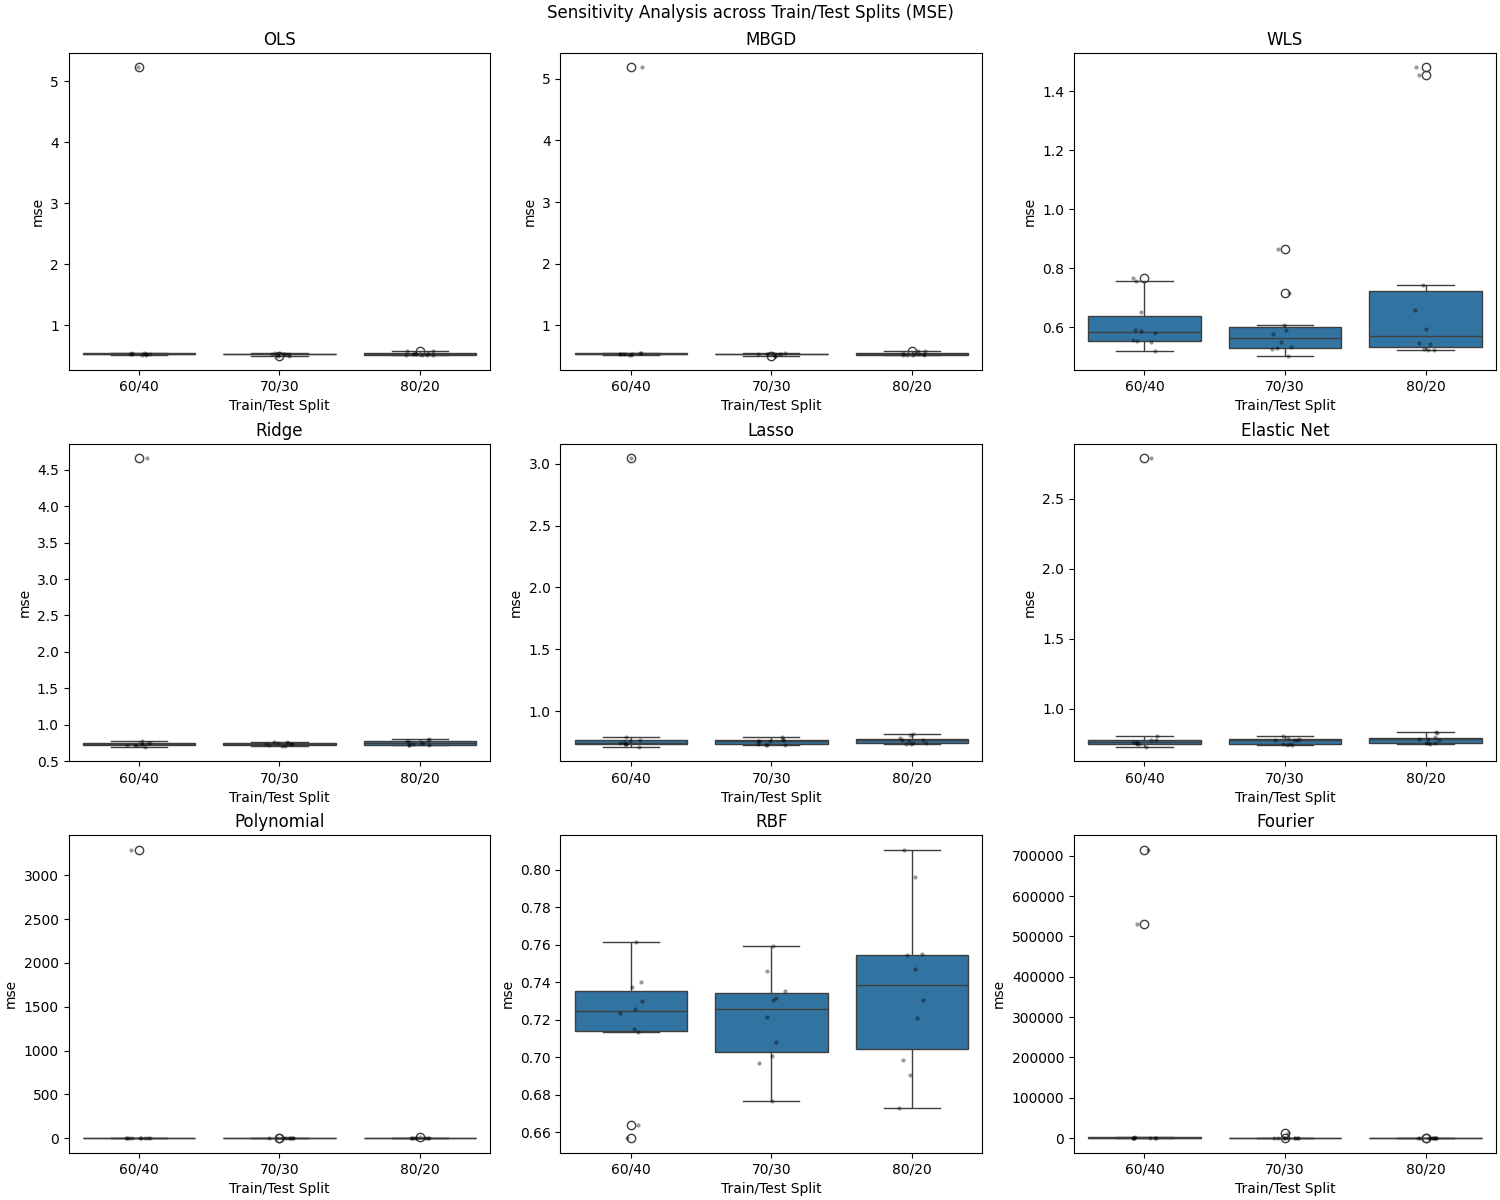

In [16]:
fig = plot_split_boxplots(df, metric="mse")
plt.show()

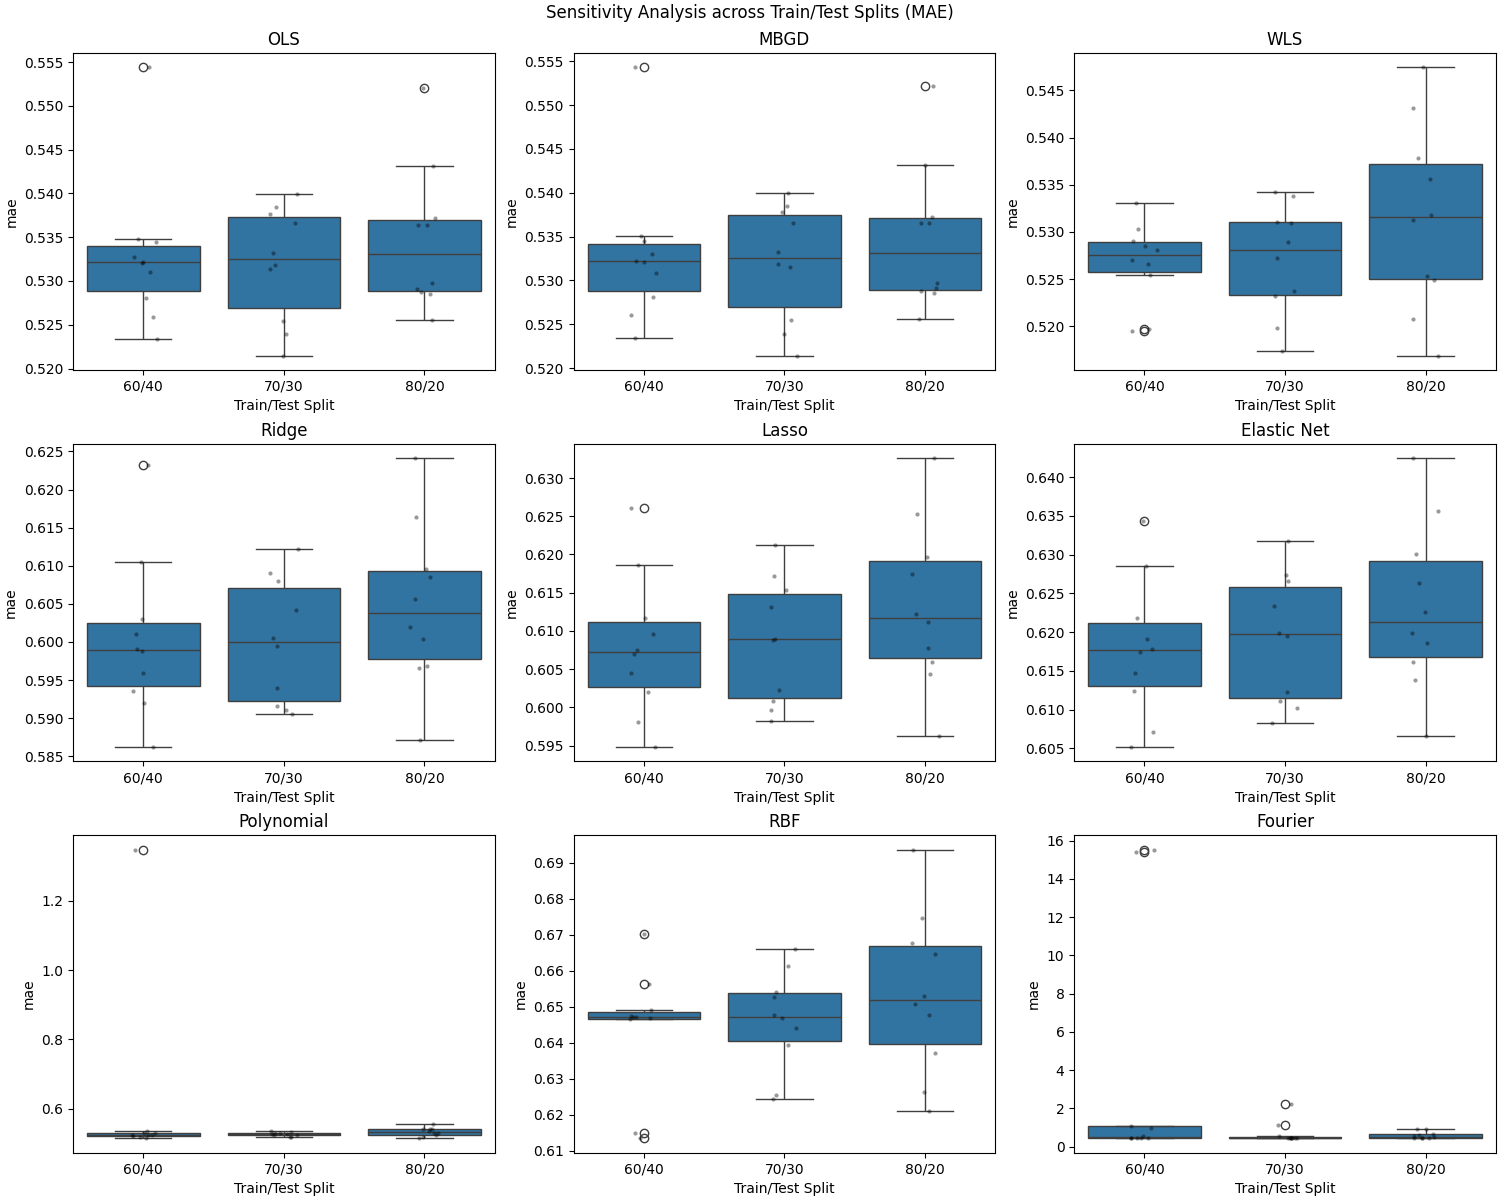

In [30]:
fig = plot_split_boxplots(df, metric="mae")
plt.show()

#### Gaussian noise sensitivity

In [18]:
result = noise_injection_analysis(models, copy.deepcopy(d), task="regression")
# result.round(4).to_csv("regression-sensitivity-gaussian-noise.csv", index=False)
display(result)

,model,sigma,mse,rmse,mae,r2,is_clean,mse_sens_abs,mse_sens_rel,rmse_sens_abs,rmse_sens_rel,mae_sens_abs,mae_sens_rel,r2_sens_abs,r2_sens_rel
0,OLS,0.0,0.524912,0.724508,0.529685,0.610048,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MBGD,0.0,0.525089,0.724630,0.529841,0.609917,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,WLS,0.0,0.531956,0.729353,0.522687,0.604816,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ridge,0.0,0.730986,0.854977,0.596158,0.456958,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Lasso,0.0,0.748882,0.865380,0.605771,0.443663,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Elastic Net,0.0,0.767259,0.875933,0.615911,0.430011,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Polynomial,0.0,0.504271,0.710120,0.519910,0.625382,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,RBF,0.0,0.657261,0.810716,0.602315,0.511728,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Fourier,0.0,0.387824,0.622755,0.446926,0.711890,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,OLS,0.1,0.536959,0.732775,0.536539,0.601099,False,0.012047,0.022950,0.008267,0.011410,0.006854,0.012941,0.008949,0.014670


#### Feature corruption with imputers sensitivity

In [19]:
result = feature_corruption_analysis(models, copy.deepcopy(d), task="regression")
# result.round(4).to_csv("regression-sensitivity-imputer.csv", index=False)
display(result)

,model,imputer,missing_rate,is_clean,mse,rmse,mae,r2,mse_sens_abs,mse_sens_rel,rmse_sens_abs,rmse_sens_rel,mae_sens_abs,mae_sens_rel,r2_sens_abs,r2_sens_rel
0,OLS,none,0.0,True,0.524912,0.724508,0.529685,0.610048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MBGD,none,0.0,True,0.525089,0.724630,0.529841,0.609917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,WLS,none,0.0,True,0.531956,0.729353,0.522687,0.604816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ridge,none,0.0,True,0.730986,0.854977,0.596158,0.456958,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Lasso,none,0.0,True,0.748882,0.865380,0.605771,0.443663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Lasso,knn,0.3,False,0.964835,0.982260,0.698308,0.283234,0.215954,0.288368,0.116881,0.135063,0.092537,0.152759,0.160430,0.361602
86,Elastic Net,knn,0.3,False,0.976865,0.988365,0.704649,0.274297,0.209605,0.273187,0.112431,0.128356,0.088738,0.144077,0.155714,0.362115
87,Polynomial,knn,0.3,False,0.851371,0.922698,0.687700,0.367525,0.347100,0.688320,0.212577,0.299354,0.167790,0.322730,0.257857,0.412319
88,RBF,knn,0.3,False,0.937366,0.968176,0.737136,0.303641,0.280105,0.426169,0.157460,0.194223,0.134821,0.223838,0.208087,0.406636


#### Loss curves

In [20]:
gd_models = {
    name: model
    for name, model in models.items()
    if isinstance(model.named_steps["predictor"], BaseGDModel)
}
display(gd_models)

{'MBGD': Pipeline(steps=[('scaler', StandardScaler()),
                 ('predictor', MBGD(lr_sched='step_decay'))]),
 'Ridge': Pipeline(steps=[('scaler', StandardScaler()),
                 ('predictor', RidgeRegression(alpha=0.1))]),
 'Lasso': Pipeline(steps=[('scaler', StandardScaler()),
                 ('predictor', LassoRegression(alpha=0.1))]),
 'Elastic Net': Pipeline(steps=[('scaler', StandardScaler()),
                 ('predictor',
                  ElasticNet(alpha_1=np.float64(0.1), alpha_2=np.float64(0.1)))])}

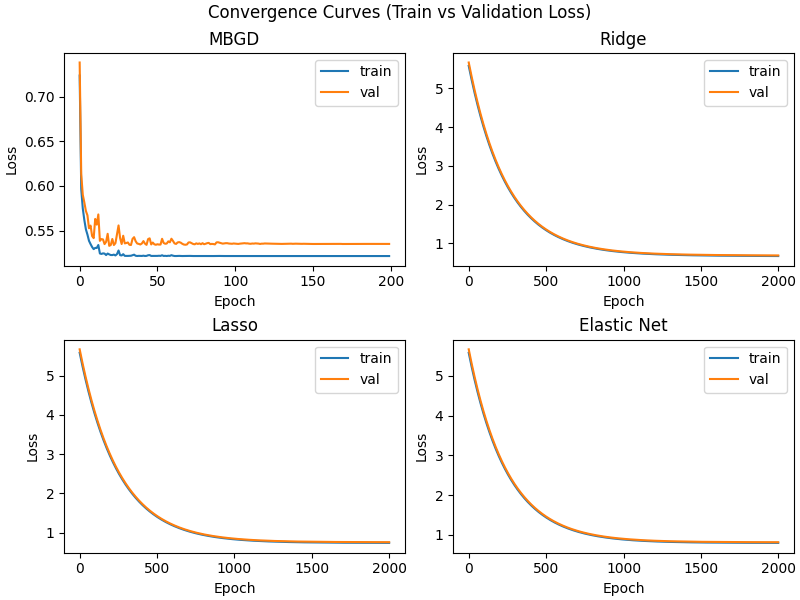

In [31]:
epochs = [200, 2000, 2000, 2000]
fig = plot_loss_curves(gd_models, copy.deepcopy(d), epochs)
fig.show()

### Benchmarks

In [22]:
bm_models = {
    name: model
    for name, model in models.items()
    if isinstance(model.named_steps["predictor"], BaseModel)
}
display(bm_models)

{'OLS': Pipeline(steps=[('scaler', StandardScaler()), ('predictor', OLS())]),
 'MBGD': Pipeline(steps=[('scaler', StandardScaler()),
                 ('predictor', MBGD(lr_sched='step_decay'))]),
 'WLS': Pipeline(steps=[('scaler', StandardScaler()), ('predictor', WLS())]),
 'Ridge': Pipeline(steps=[('scaler', StandardScaler()),
                 ('predictor', RidgeRegression(alpha=0.1))]),
 'Lasso': Pipeline(steps=[('scaler', StandardScaler()),
                 ('predictor', LassoRegression(alpha=0.1))]),
 'Elastic Net': Pipeline(steps=[('scaler', StandardScaler()),
                 ('predictor',
                  ElasticNet(alpha_1=np.float64(0.1), alpha_2=np.float64(0.1)))]),
 'Polynomial': Pipeline(steps=[('scaler', StandardScaler()),
                 ('features', PolynomialBasis(degree=2)), ('predictor', OLS())]),
 'RBF': Pipeline(steps=[('scaler', StandardScaler()), ('features', RBF()),
                 ('predictor', OLS())]),
 'Fourier': Pipeline(steps=[('scaler', StandardScaler()

In [23]:
result = benchmark_models(bm_models, d)
# result.round(4).to_csv("regression-benchmark-models.csv")
display(result)

,model,train_time_mean,train_time_std,train_memory_mean,train_memory_std,inference_time_mean,inference_time_std,inference_memory_mean,inference_memory_std
0,OLS,0.003085,0.001708,1329249.8,3686.653898,0.000251,3.497052e-04,68195.4,2725.415682
1,MBGD,2.063587,0.023515,2518517.6,1887.457719,0.000026,3.316696e-06,66368.0,0.000000
2,WLS,0.004419,0.000229,4758065.0,0.000000,0.000030,2.978570e-06,66344.0,0.000000
3,Ridge,0.592653,0.007809,2511564.8,249.600000,0.000021,9.086107e-07,66344.0,0.000000
4,Lasso,0.589782,0.004823,2511440.0,0.000000,0.000022,7.844962e-07,66344.0,0.000000
5,Elastic Net,0.606384,0.008371,2511472.0,0.000000,0.000023,3.794837e-06,66344.0,0.000000
6,Polynomial,0.001199,0.000009,2378280.0,0.000000,0.000040,2.681506e-06,66344.0,0.000000
7,RBF,0.001081,0.000142,1585704.0,0.000000,0.000059,8.575019e-06,66344.0,0.000000
8,Fourier,0.006999,0.000034,10966401.0,0.000000,0.000213,1.290557e-05,66344.0,0.000000
